# 2. Intraday momentum strategy on SPY: backtest

Replication and extension of Zarattini, Aziz and Barbon (2025),
*Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY)*.

Contents:
1. Settings and data
2. Strategy functions (noise band, positions, returns, metrics)
3. Sanity check against the paper's example days
4. Baseline results with train/test split
5. Parameter sensitivity (train period only)
6. Own variation: RSI-tilted position sizing

## 1. Settings and data

In [1]:
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "/content/drive/MyDrive/spy_1min.parquet"

LOOKBACK = 14                     # days used for the noise band (paper: 14)
MULTIPLIER = 1.0                  # width of the noise band (paper: 1)
COST_PER_SHARE = 0.0035 + 0.001   # commission + slippage per share (paper)
TARGET_VOL = 0.02                 # daily volatility target for sizing (paper: 2%)
MAX_LEVERAGE = 4                  # leverage cap (paper: 4x)
VOL_WINDOW = 14                   # days used to measure SPY volatility
WARMUP = 100                      # first days skipped, same for every setting
SPLIT = dt.date(2022, 1, 1)       # train: before this date, test: from this date

In [2]:
from google.colab import drive
drive.mount("/content/drive")

spy = pd.read_parquet(DATA_FILE)
print("Rows:", len(spy))

Mounted at /content/drive
Rows: 1052278


In [3]:
# Label every bar with its day and its time of day
spy["date"] = spy.index.date
spy["time"] = spy.index.time

# Keep only full trading days (drops the few early-close days)
bars_per_day = spy.groupby("date").size()
full_days = bars_per_day[bars_per_day >= 380].index
print("Days dropped:", len(bars_per_day) - len(full_days))
spy = spy[spy["date"].isin(full_days)]

# Grids: one row per day, one column per minute
close = spy.pivot(index="date", columns="time", values="close").ffill(axis=1)
high = spy.pivot(index="date", columns="time", values="high")
low = spy.pivot(index="date", columns="time", values="low")
volume = spy.pivot(index="date", columns="time", values="volume")

# Daily series
day_open = spy.groupby("date")["open"].first()
day_close = spy.groupby("date")["close"].last()
prev_close = day_close.shift(1)

# Running VWAP since the open
typical_price = (high + low + close) / 3
vwap = (typical_price * volume).cumsum(axis=1) / volume.cumsum(axis=1)

# Decisions are allowed only at HH:00 and HH:30, from 10:00
decision_times = [t for t in close.columns
                  if t.minute in (0, 30) and t >= dt.time(10, 0)]

# Volatility-targeted leverage, using information up to yesterday
spy_daily_return = day_close.pct_change()
recent_vol = spy_daily_return.rolling(VOL_WINDOW).std().shift(1)
leverage = (TARGET_VOL / recent_vol).clip(upper=MAX_LEVERAGE)

print("Shape:", close.shape)
print("Missing values:", close.isna().sum().sum())

Days dropped: 24
Shape: (2677, 390)
Missing values: 0


## 2. Strategy functions

In [4]:
def noise_band(lookback=LOOKBACK, multiplier=MULTIPLIER):
    """Upper and lower boundary of the noise area, for every day and minute."""
    move = (close.div(day_open, axis=0) - 1).abs()
    sigma = move.rolling(lookback).mean().shift(1)      # previous days only
    upper = (1 + multiplier * sigma).mul(np.maximum(day_open, prev_close), axis=0)
    lower = (1 - multiplier * sigma).mul(np.minimum(day_open, prev_close), axis=0)
    return upper, lower


def compute_position(lookback=LOOKBACK, multiplier=MULTIPLIER):
    """Position per minute: +1 long, -1 short, 0 flat."""
    upper, lower = noise_band(lookback, multiplier)
    go_long = (close > upper) & (close > vwap)
    go_short = (close < lower) & (close < vwap)
    signal = go_long.astype(int) - go_short.astype(int)
    # Take the signal at decision times and hold it until the next one
    return (signal[decision_times]
            .reindex(columns=close.columns).ffill(axis=1).fillna(0))


def run_backtest(lookback=LOOKBACK, multiplier=MULTIPLIER, sizing=True):
    """Daily strategy returns after commission and slippage."""
    position = compute_position(lookback, multiplier)
    held = position.shift(1, axis=1).fillna(0)          # position going into each minute
    pnl_per_share = (held * close.diff(axis=1)).sum(axis=1)
    trades = position.diff(axis=1).abs().sum(axis=1) + position.iloc[:, -1].abs()
    net = (pnl_per_share - trades * COST_PER_SHARE) / day_open
    if sizing:
        net = net * leverage
    return net.iloc[WARMUP:]


def performance(daily_returns):
    """Annualized return, annualized volatility and Sharpe ratio (risk-free rate = 0)."""
    years = len(daily_returns) / 252
    ann_return = (1 + daily_returns).prod() ** (1 / years) - 1
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
    return {"Ann. return %": round(ann_return * 100, 1),
            "Ann. volatility %": round(ann_vol * 100, 1),
            "Sharpe": round(sharpe, 2)}


def summarize(returns):
    """Performance for the train and the test period."""
    return pd.DataFrame({
        "Train": performance(returns[returns.index < SPLIT]),
        "Test": performance(returns[returns.index >= SPLIT]),
    }).T


def plot_day(day):
    """Price, noise area, VWAP and the strategy's position on one day."""
    upper, lower = noise_band()
    position = compute_position().loc[day]
    labels = [t.strftime("%H:%M") for t in close.columns]
    x = range(len(labels))

    plt.figure(figsize=(10, 5))
    plt.plot(close.loc[day].values, color="black", label="SPY")
    plt.plot(vwap.loc[day].values, color="red", linestyle=":", label="VWAP")
    plt.fill_between(x, lower.loc[day].values, upper.loc[day].values,
                     color="gold", alpha=0.3, label="Noise area")
    plt.axhline(prev_close.loc[day], color="grey", linestyle="--", label="Previous close")
    ymin, ymax = plt.ylim()
    plt.fill_between(x, ymin, ymax, where=(position.values > 0), color="green", alpha=0.08, label="Long")
    plt.fill_between(x, ymin, ymax, where=(position.values < 0), color="red", alpha=0.08, label="Short")
    plt.ylim(ymin, ymax)
    plt.xticks(range(0, len(labels), 30), labels[::30], rotation=90)
    plt.title(f"SPY and noise area on {day}")
    plt.legend(loc="best", fontsize=8)
    plt.show()

## 3. Sanity check against the paper

The paper shows 31 January 2022 (Figure 2a: long from 10:30 to the close, +1.23%)
and 20 January 2022 (Figure 5b: long at 10:00, stopped out at 13:00, about 0%).

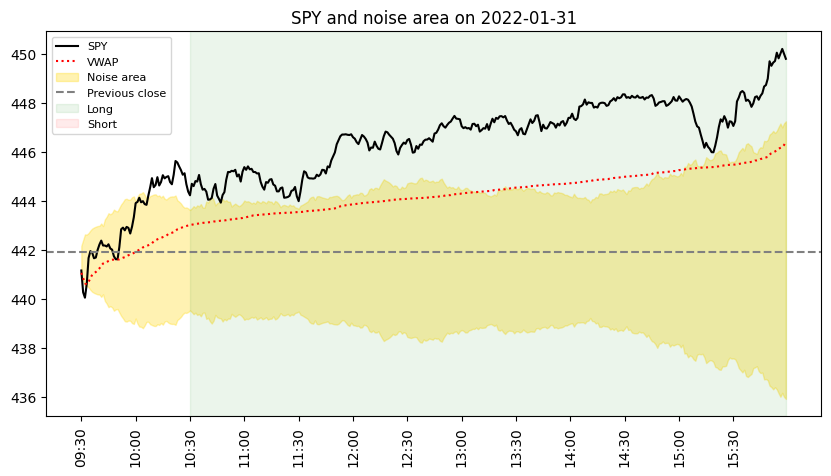

2022-01-31 return after costs: 1.26 %


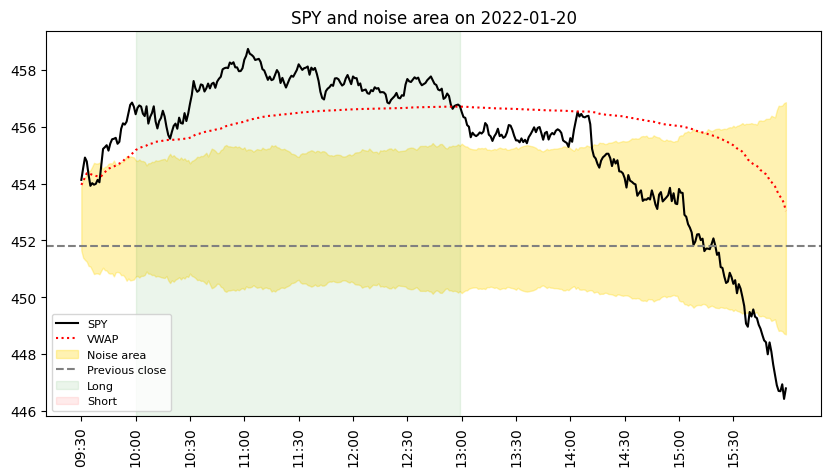

2022-01-20 return after costs: 0.02 %


In [5]:
base = run_backtest(sizing=False)

for day in [dt.date(2022, 1, 31), dt.date(2022, 1, 20)]:
    plot_day(day)
    print(day, "return after costs:", round(base.loc[day] * 100, 2), "%")

## 4. Baseline results

In [6]:
baseline = run_backtest(sizing=True)
buy_hold = day_close.pct_change().loc[baseline.index]

print("Average leverage:", round(leverage.loc[baseline.index].mean(), 2))

results = pd.concat({
    "Base (100% size)": summarize(base),
    "Baseline (vol. sizing)": summarize(baseline),
    "SPY buy & hold": summarize(buy_hold),
})
results

Average leverage: 2.66


Ann. return %  Ann. volatility %  Sharpe
Base (100% size)       Train            6.8                6.4    1.06
                       Test             4.7                6.7    0.72
Baseline (vol. sizing) Train           16.0               14.9    1.07
                       Test            10.3               14.6    0.75
SPY buy & hold         Train           15.9               16.6    0.98
                       Test            10.6               17.2    0.67

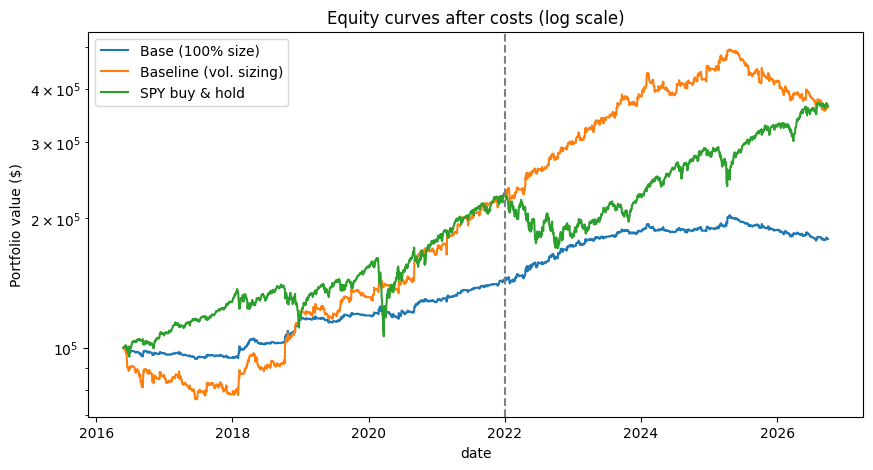

In [7]:
# Equity curves, starting from $100,000
curves = pd.DataFrame({
    "Base (100% size)": base,
    "Baseline (vol. sizing)": baseline,
    "SPY buy & hold": buy_hold,
})
equity = 100_000 * (1 + curves).cumprod()

ax = equity.plot(figsize=(10, 5), logy=True, title="Equity curves after costs (log scale)")
ax.axvline(SPLIT, color="grey", linestyle="--")
ax.set_ylabel("Portfolio value ($)")
plt.show()

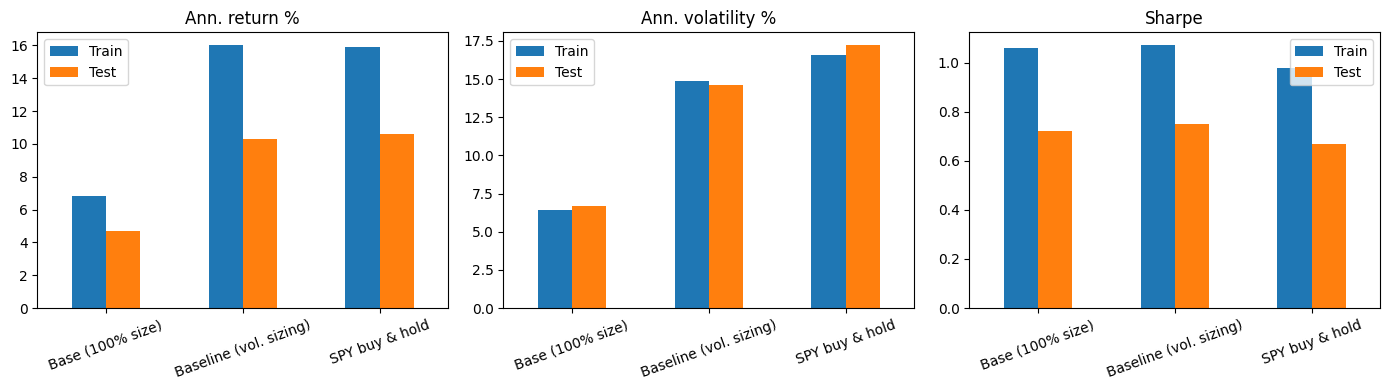

In [8]:
# The three metrics side by side, train vs test
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["Ann. return %", "Ann. volatility %", "Sharpe"]):
    results[metric].unstack().plot(kind="bar", ax=ax, title=metric, rot=20)
plt.tight_layout()
plt.show()

## 5. Parameter sensitivity (train period only)

Sharpe ratio on the train period for different lookbacks and band multipliers.
The test period is not used here.

In [9]:
lookbacks = [7, 14, 30, 60, 90]
multipliers = [0.8, 1.0, 1.2, 1.5]

rows = []
for lb in lookbacks:
    for m in multipliers:
        returns = run_backtest(lookback=lb, multiplier=m, sizing=True)
        train = returns[returns.index < SPLIT]
        rows.append({"lookback": lb, "multiplier": m,
                     "train_sharpe": performance(train)["Sharpe"]})

grid = pd.DataFrame(rows).pivot(index="lookback", columns="multiplier",
                                values="train_sharpe")
grid

multiplier,0.8,1.0,1.2,1.5
lookback,,,,
7,0.92,0.78,0.78,0.72
14,0.74,1.07,0.93,0.91
30,0.93,0.78,0.89,0.94
60,0.97,0.79,0.73,0.83
90,0.92,0.85,0.79,0.95


## 6. Own variation: RSI-tilted position sizing

Hypothesis (paper, section 4.5): after market declines dealers tend to be short gamma and amplify
intraday trends, so the strategy should earn more when the 5-day RSI is low.
Rule: scale the position up after declines and down after rallies.

In [10]:
# 5-day RSI of SPY, as known at yesterday's close
change = day_close.diff()
avg_gain = change.clip(lower=0).rolling(5).mean()
avg_loss = (-change.clip(upper=0)).rolling(5).mean()
rsi = (100 * avg_gain / (avg_gain + avg_loss)).shift(1)


def return_by_rsi(returns):
    """Average daily strategy return (basis points) by yesterday's RSI group."""
    groups = pd.cut(rsi.reindex(returns.index), bins=[0, 30, 50, 70, 100],
                    include_lowest=True)
    table = returns.groupby(groups, observed=True).agg(["count", "mean"])
    table["mean"] = (table["mean"] * 10000).round(1)
    return table


# Step 1: does the hypothesis hold in the TRAIN period?
return_by_rsi(baseline[baseline.index < SPLIT])

,count,mean
close,,
"(-0.001, 30.0]",211,20.8
"(30.0, 50.0]",296,9.0
"(50.0, 70.0]",352,1.1
"(70.0, 100.0]",537,2.6


In [11]:
# Step 2: the rule. Tilt between 0.5x and 1.5x, total leverage still capped
tilt = (1 + (50 - rsi) / 50).clip(lower=0.5, upper=1.5)
variation_leverage = (leverage * tilt).clip(upper=MAX_LEVERAGE)
variation = base * variation_leverage.loc[base.index]

print("Average leverage, baseline: ", round(leverage.loc[base.index].mean(), 2))
print("Average leverage, variation:", round(variation_leverage.loc[base.index].mean(), 2))

pd.concat({
    "Baseline": summarize(baseline),
    "RSI-tilted variation": summarize(variation),
})

Average leverage, baseline:  2.66
Average leverage, variation: 2.22


Ann. return %  Ann. volatility %  Sharpe
Baseline             Train           16.0               14.9    1.07
                     Test            10.3               14.6    0.75
RSI-tilted variation Train           19.0               15.3    1.21
                     Test             7.5               15.1    0.55

In [12]:
# Step 3: diagnosis. Did the RSI pattern persist in the TEST period?
return_by_rsi(baseline[baseline.index >= SPLIT])

,count,mean
close,,
"(-0.001, 30.0]",236,-1.4
"(30.0, 50.0]",257,3.8
"(50.0, 70.0]",303,13.8
"(70.0, 100.0]",385,0.7


## 7. Second hypothesis: trend filter on short trades (rejected on train data)

In [13]:
# 200-day average of SPY, as known at yesterday's close
sma200 = day_close.rolling(200).mean().shift(1)
uptrend = prev_close > sma200


def side_returns(side):
    """Daily returns from long trades only (side=1) or short trades only (side=-1)."""
    position = compute_position()
    position = position.where(position == side, 0)
    held = position.shift(1, axis=1).fillna(0)
    pnl_per_share = (held * close.diff(axis=1)).sum(axis=1)
    trades = position.diff(axis=1).abs().sum(axis=1) + position.iloc[:, -1].abs()
    net = (pnl_per_share - trades * COST_PER_SHARE) / day_open * leverage
    return net.iloc[WARMUP:]


long_part = side_returns(1)
short_part = side_returns(-1)
print("Long + short equals baseline:", np.allclose(long_part + short_part, baseline))

# TRAIN period only, and only days where the 200-day average exists
days = baseline.index[(baseline.index < SPLIT) & sma200.loc[baseline.index].notna()]
regime = uptrend.loc[days].map({True: "Uptrend", False: "Downtrend"})

trend_check = pd.DataFrame({
    "days": regime.value_counts(),
    "long trades (bp/day)": (long_part.loc[days].groupby(regime).mean() * 10000).round(1),
    "short trades (bp/day)": (short_part.loc[days].groupby(regime).mean() * 10000).round(1),
})
trend_check

Long + short equals baseline: True


,days,long trades (bp/day),short trades (bp/day)
close,,,
Downtrend,139,11.0,-0.7
Uptrend,1157,3.8,3.7


## 8. Ablation: switching off one building block at a time

In [14]:
def run_variant(use_vwap=True, gap_adjust=True, shorts=True, first_trade=dt.time(10, 0)):
    """Baseline with one building block switched off. Returns daily returns after costs."""
    move = (close.div(day_open, axis=0) - 1).abs()
    sigma = move.rolling(LOOKBACK).mean().shift(1)
    upper_anchor = np.maximum(day_open, prev_close) if gap_adjust else day_open
    lower_anchor = np.minimum(day_open, prev_close) if gap_adjust else day_open
    upper = (1 + sigma).mul(upper_anchor, axis=0)
    lower = (1 - sigma).mul(lower_anchor, axis=0)

    go_long = close > upper
    go_short = close < lower
    if use_vwap:
        go_long = go_long & (close > vwap)
        go_short = go_short & (close < vwap)
    signal = go_long.astype(int) - (go_short.astype(int) if shorts else 0)

    times = [t for t in decision_times if t >= first_trade]
    position = signal[times].reindex(columns=close.columns).ffill(axis=1).fillna(0)

    held = position.shift(1, axis=1).fillna(0)
    pnl_per_share = (held * close.diff(axis=1)).sum(axis=1)
    trades = position.diff(axis=1).abs().sum(axis=1) + position.iloc[:, -1].abs()
    net = (pnl_per_share - trades * COST_PER_SHARE) / day_open * leverage
    return net.iloc[WARMUP:]


variants = {
    "Baseline (everything on)": run_variant(),
    "Without VWAP condition": run_variant(use_vwap=False),
    "Without gap adjustment": run_variant(gap_adjust=False),
    "Without short trades": run_variant(shorts=False),
    "No trades before 10:30": run_variant(first_trade=dt.time(10, 30)),
}
print("Baseline reproduced:", np.allclose(variants["Baseline (everything on)"], baseline))

ablation = pd.DataFrame({
    name: {"Train Sharpe": performance(r[r.index < SPLIT])["Sharpe"],
           "Test Sharpe": performance(r[r.index >= SPLIT])["Sharpe"],
           "Train return %": performance(r[r.index < SPLIT])["Ann. return %"],
           "Test return %": performance(r[r.index >= SPLIT])["Ann. return %"]}
    for name, r in variants.items()
}).T
ablation

Baseline reproduced: True


,Train Sharpe,Test Sharpe,Train return %,Test return %
Baseline (everything on),1.07,0.75,16.0,10.3
Without VWAP condition,0.96,0.68,14.6,9.2
Without gap adjustment,0.93,1.19,15.4,21.3
Without short trades,1.27,0.69,10.4,5.8
No trades before 10:30,0.84,0.85,11.7,11.2
